# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [2]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


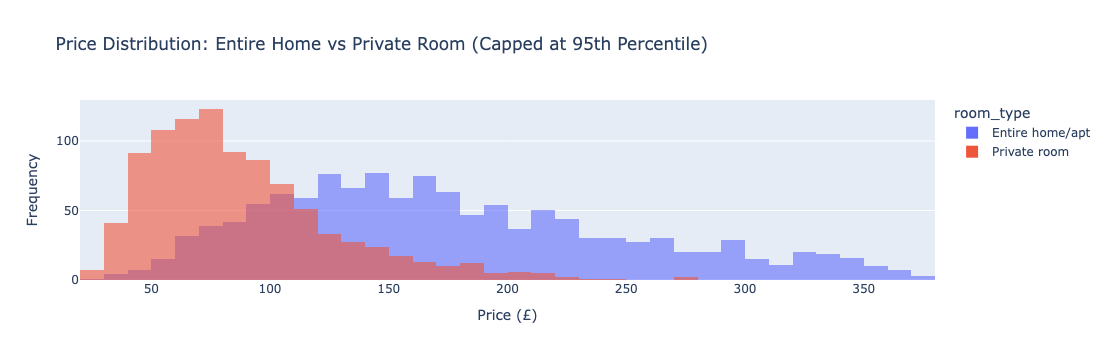

In [3]:
# Task 1
# YOUR CODE HERE
# Task 1

# Filter only relevant room types
df_filtered = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Create histogram
fig = px.histogram(
    df_filtered,
    x='price',
    color='room_type',
    barmode='overlay',  # overlapping
    nbins=50,
    opacity=0.6,
    title='Price Distribution: Entire Home vs Private Room (Capped at 95th Percentile)'
)

# Add labels
fig.update_layout(
    xaxis_title='Price (£)',
    yaxis_title='Frequency'
)

fig.show()

In [4]:
df_reviews = df_cap.dropna(subset=['reviews_per_month'])

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

In [6]:
print(df_cap.columns)

Index(['neighbourhood', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'availability_365', 'reviews_per_month'],
      dtype='object')


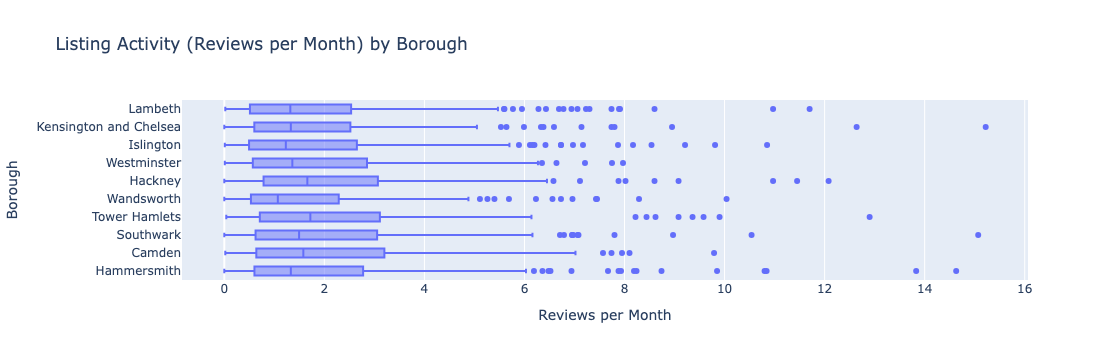

In [7]:
# Task 2
# YOUR CODE HERE
# Task 2

# Remove missing values
df_reviews = df_cap.dropna(subset=['reviews_per_month'])

# Optional: limit to top boroughs (cleaner plot)
top_boroughs = df_reviews['neighbourhood'].value_counts().head(10).index
df_reviews = df_reviews[df_reviews['neighbourhood'].isin(top_boroughs)]

# Create horizontal box plot
fig = px.box(
    df_reviews,
    x='reviews_per_month',
    y='neighbourhood',
    orientation='h',
    title='Listing Activity (Reviews per Month) by Borough'
)

# Labels
fig.update_layout(
    xaxis_title='Reviews per Month',
    yaxis_title='Borough'
)

fig.show()